In [1]:
### 05_의사결정나무 모델 만들기

In [2]:
# 전처리가 끝났으니 모델을 만드는 작업
# 모델을 만들 때는 df_train을 사용하고, 모델이 만들어 진 후 모델을 평가할 때 df_test를 사용

In [3]:
### 1. 모델 설정하기

In [4]:
# 의사결정나무 모델을 만들 때 sklearn의 DecisionTreeClassifier 클래스를 이요

# * DecisionTreeClassifier의 파라미터

# random_state : 난수 초기값. 변수 선택 과정에서 난수를 이용하기 때문에 코드를 실행할 때마다 결과가 조금씩 달라짐
# 난수를 고정하면 코드를 여러 번 실행해도 결과가 항상 같음

# max_depth : 나무의 깊이. 노드를 최대 몇 번까지 분할할지 정함
# 숫자가 클수록 노드를 여러 번 분할 해 복잡한 모델을 만듬
# 값을 지정하지 않으면 노드를 최대한 많이 분할. 단순한 모델을 만들기 위해 3을 입력

In [5]:
import pandas as pd

df_train = pd.read_pickle('./output/df_train_02.pickle')

In [6]:
from sklearn import tree
clf = tree.DecisionTreeClassifier(random_state=1234, # 난수 고정
                                  max_depth=3) # 나무 깊이

In [7]:
### 2. 모델 만들기

In [8]:
# df_train에서 예측 변수와 타겟 변수를 각각 추출해 데이터 프레임을 만듦
# clf.fit()의 X에는 예측 변수, y에는 타겟 변수를 입력

In [9]:
train_x = df_train.drop(columns='income') # 예측 변수 추출
train_y = df_train['income'] # 타켓 변수 추출

In [10]:
model = clf.fit(X=train_x, y=train_y) # 모델 만들기

In [11]:
### 3. 모델 구조 살펴보기

In [12]:
# 완성된 모델을 그래프로 만들어 구조를 살펴봄
# tree.plot_tree()을 이용하면 모델을 시각화할 수 있음

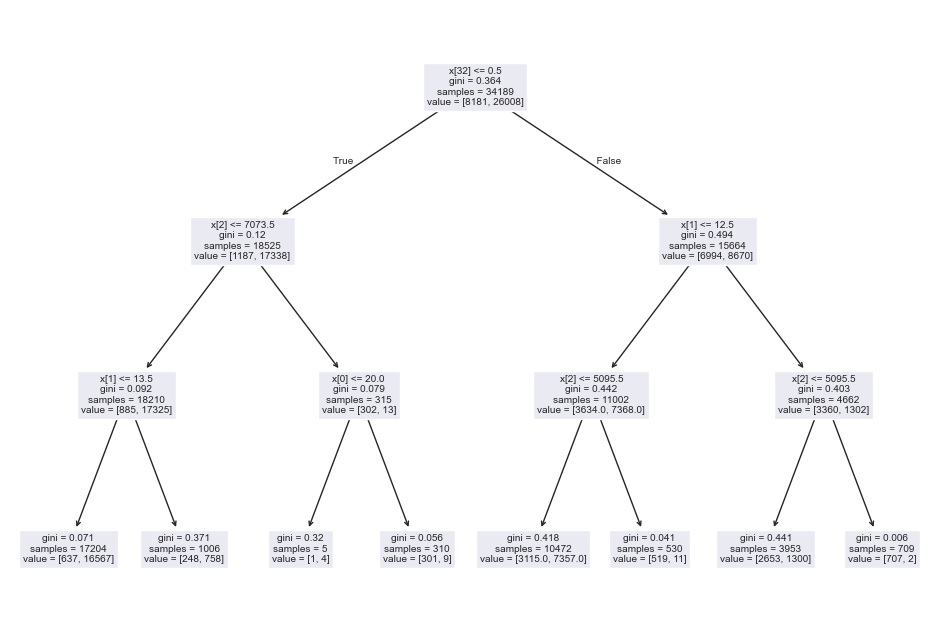

In [13]:
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': [12, 8], # 그래프 크기 설정
                     'figure.dpi': '100'}) # 해상도 설정

tree.plot_tree(model)
plt.show()

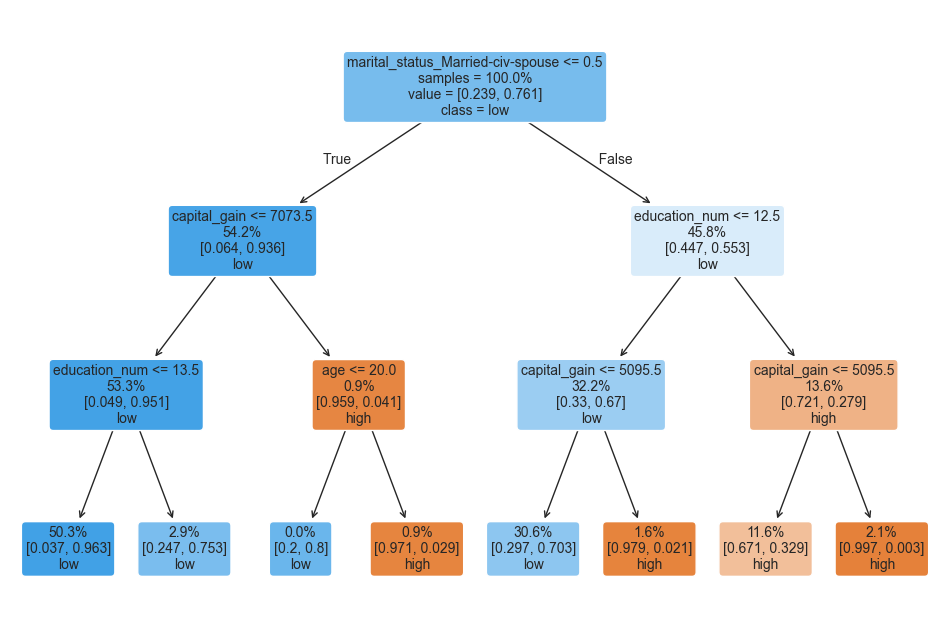

In [15]:
# tree.plot_tree()에 몇 가지 파라미터를 추가해 그래프를 보기 좋게 수정
tree.plot_tree(model,
               feature_names=train_x.columns,
               class_names=['high', 'low'],
               proportion=True,
               filled=True,
               rounded=True,
               impurity=False,
               label='root',
               fontsize=10)
plt.show()

In [16]:
# 1) 노드의 값

# a. 첫 번째 노드
# marital_status_Married-civ-spouse <= 0.5
# samples = 100.0%
# value = [0.239, 0.761]
# class = low

In [17]:
# marital_status 결혼 상태
# marital_status_Married-civ-spouse <= 0.5 : 분리 기준
# 노드를 분리할 때 사용할 기준을 나타냄
# 이 기준을 충족하는 데이터는 왼쪽, 충족하지 않은 데이터는 오른쪽 노드로 할당
# marital_status_Married-civ-spouse는 원핫 인코딩으로 만들어진 변수로 기혼이면 1, 비혼이면 0으로 되어 있음
# 따라서 비혼이면 변수의 값이 0이므로 'marital_status_Married-civ-spouse <= 0.5(비혼)' 조건을 충족해 왼쪽 노드로 내려가고,
# 기혼이면 조건을 충족하지 않으므로 오른쪽으로 내려감
# 즉, 비혼은 왼쪽 노드, 기혼은 오른쪽 노드로 내려감
# 다른 노드도 분리 기준이 표시되지만 마지막 단계의 '끝 노드'는 더이상 나뉘지 않으므로 분리 기준이 표시되지 않음

In [18]:
# samples = 100.0% : 노드에 해당하는 관측치 비율
# 전체 데이터의 몇 퍼센트가 해당 노드에 분류됐는지 나타냄
# 첫 번째 노드는 아직 한 번도 나뉘지 않았으므로 데이터의 100%가 이 노드에 속함
# 다음 단계의 노드로 내려가면 데이터가 여러 노드로 분리되므로 비율이 줄어듦
# 예를 들어 두 번째 노드를 보면 왼쪽 노드는 54.2%, 오른쪽 노드는 45.8%여서 같은 단계의 노드 비율을 모두 더하면 100%

In [19]:
# value = [0.239, 0.761] : 타켓 변수의 클래스별 비율
# 타켓 변수의 클래스별 비율이 알파벳 순으로 나타남
# 타켓 변수 income의 'high', 'low' 중 'high'가 알파벳순으로 우선하므로
# 'high', 'low' 순으로 비율이 표시
# 값을 보면 전체 데이터 중 'high'가 23.9%, 'low'가 76.1%라는 것을 알 수 있음

In [20]:
# class = low : 우세한 클래스(0.5 기준)
# 0.5를 기준으로 타겟 변수의 두 클래스 중 어느쪽이 더 많은지 나타냄
# 'high'가 23.9%, 'low'가 76.1%로 'low'가 더 많으므로 'low'가 표시

In [21]:
# b. 왼쪽 노드
# 첫 번째 노드의 조건 'marital_status_Married-civ-spouse <= 0.5(비혼)'을 충족한 비혼자가 이 노드에 할당
# capital_gain  자본 소득(USD)
# capital_gain <= 7073.5
# 54.2%
# [0.064, 0.936]
# low
# 비혼자는 전체의 54.2%
# 비혼자의 income은 'high' 6.4%, 'low' 93.6%로 'low'가 더 많음
# 다음으로 노드를 나누는 기준은 'capital_gain <= 7073.5'

In [22]:
# c. 오른쪽 노드
# 첫 번째 노드의 조건 'marital_status_Married-civ-spouse <= 0.5(비혼)'을 충족하지 않은 기혼자가 이 노드에 할당
# education_num <= 12.5
# 45.8%
# [0.447, 0.553]
# low
# 기혼자는 전체의 45.8%
# 기혼자의 income은 'high' 44.7%, 'low' 55.3%으로 'low'가 더 많음
# 다음으로 노드를 나누는 기준은 'education_num <= 12.5'

In [23]:
# 2) 노드의 색
# a. 노드의 색깔
# 노드의 색깔을 우세한 타켓 변수의 클래스에 따라 정해짐
# 그래프를 보면 'high'의 비율이 높은 노드는 주황색, 'low'의 비율이 높은 노드는 파란색 계열로 표현

# b. 노드의 색농도(흰배경 기준)
# 노드의 색농도는 '한 클래스의 구성 비율이 우세한 정도'를 나타냄
# 한 클래스의 비율이 다른 클래스보다 높을수록 농도가 진하고, 두 클래스의 비율이 비슷할수록 농도가 연함
# 두 번째 단계의 노드를 보면 왼쪽 노드는 'high'보다 'low'의 비율이 월등히 높아 농도가 진한 반면,
# 오른쪽 노드는 두 클래스의 비율이 비슷하므로 농도가 연함